# Global Suicide Rates Analysis (2000–2021)

This project analyzes global suicide rate trends across countries, genders, and age groups.

Goals:
- Explore global suicide rate trends
- Compare male vs female suicide rates
- Identify high-risk countries
- Analyze age-group differences

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("archive/tassi-di-suicidio-globali-per-paese-2000-2021.csv")

df.head()

,iso_code,country,year,sex,age_group,suicide_rate
0,AFG,Afghanistan,2000,male,ALL,5.793457
1,AFG,Afghanistan,2000,both,ALL,4.356148
2,AFG,Afghanistan,2000,female,ALL,2.910393
3,AFG,Afghanistan,2001,male,ALL,5.831328
4,AFG,Afghanistan,2001,both,ALL,4.383031


In [4]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (18315, 6)
<class 'pandas.DataFrame'>
RangeIndex: 18315 entries, 0 to 18314
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   iso_code      18315 non-null  str    
 1   country       18315 non-null  str    
 2   year          18315 non-null  int64  
 3   sex           18315 non-null  str    
 4   age_group     18315 non-null  str    
 5   suicide_rate  18315 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 858.6 KB


,year,suicide_rate
count,18315.000000,18315.000000
mean,2014.000000,10.407798
std,7.164924,11.525414
min,2000.000000,0.000000
25%,2008.000000,3.432448
50%,2016.000000,6.837156
75%,2021.000000,13.080171
max,2021.000000,160.594452


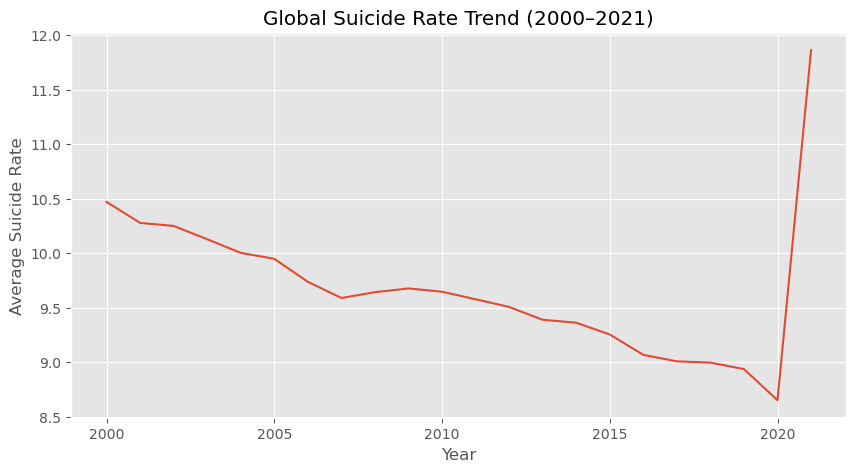

In [5]:
global_trend = df.groupby("year")["suicide_rate"].mean()

plt.figure(figsize=(10,5))

plt.plot(global_trend)

plt.title("Global Suicide Rate Trend (2000–2021)")
plt.xlabel("Year")
plt.ylabel("Average Suicide Rate")

plt.show()

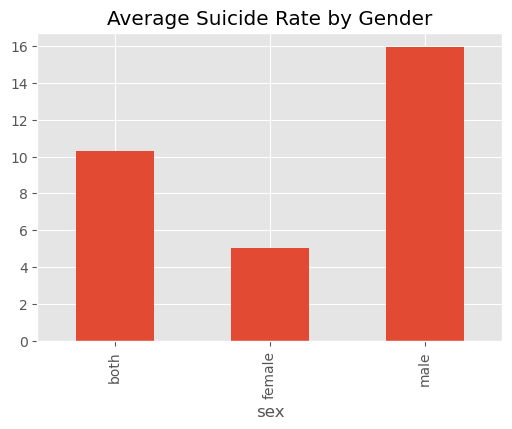

In [6]:

gender_rates = df.groupby("sex")["suicide_rate"].mean()

plt.figure(figsize=(6,4))

gender_rates.plot(kind="bar")

plt.title("Average Suicide Rate by Gender")

plt.show()

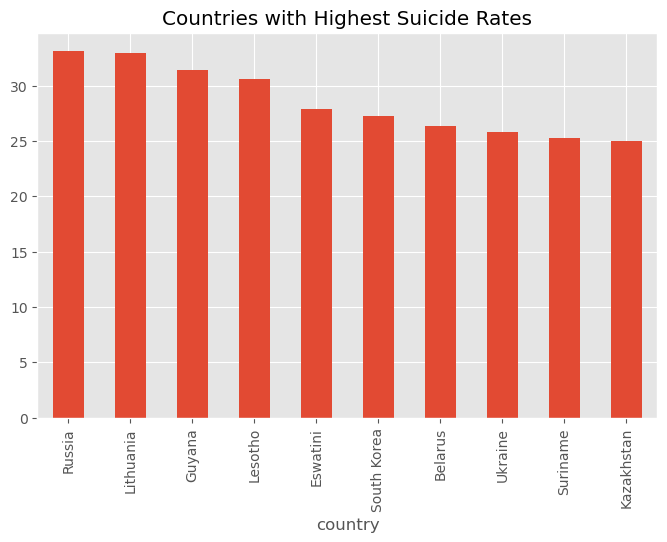

In [7]:
country_rates = df.groupby("country")["suicide_rate"].mean()

top10 = country_rates.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

top10.plot(kind="bar")

plt.title("Countries with Highest Suicide Rates")

plt.show()

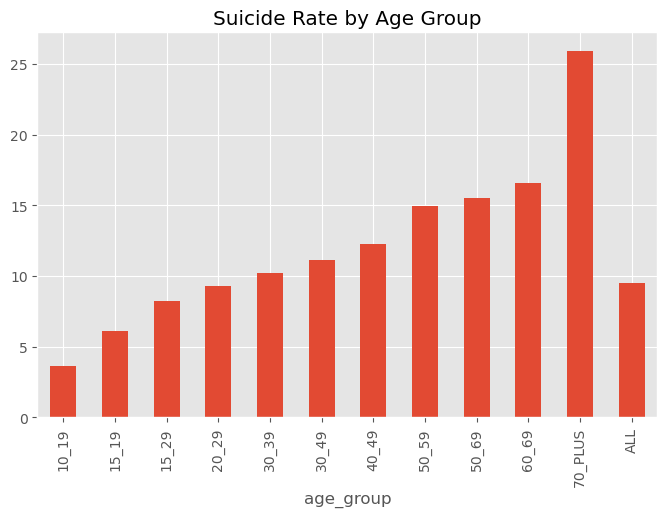

In [8]:
age_rates = df.groupby("age_group")["suicide_rate"].mean()

plt.figure(figsize=(8,5))

age_rates.plot(kind="bar")

plt.title("Suicide Rate by Age Group")

plt.show()

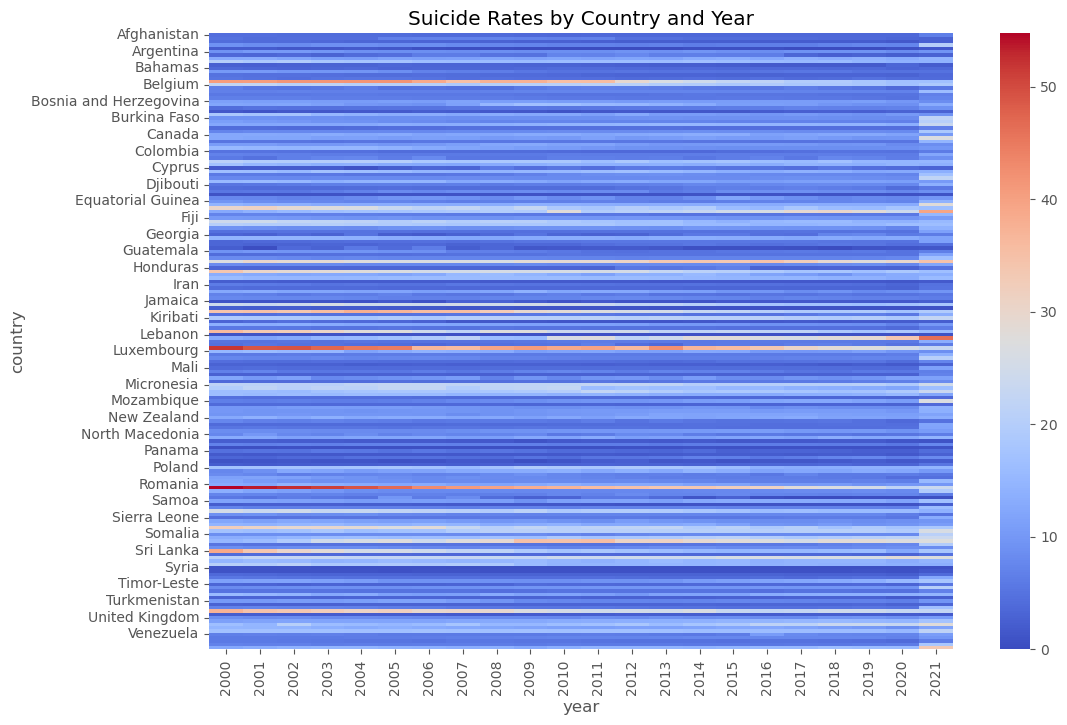

In [9]:
heatmap_data = df.pivot_table(
    values="suicide_rate",
    index="country",
    columns="year"
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm"
)

plt.title("Suicide Rates by Country and Year")

plt.show()

In [10]:
print("Highest Suicide Rate Country:")

print(country_rates.idxmax())

print("Average Global Suicide Rate:")

print(df["suicide_rate"].mean())

Highest Suicide Rate Country:
Russia
Average Global Suicide Rate:
10.40779805628201


## Global Suicide Rate Map

This visualization shows the geographic distribution of suicide rates across countries.

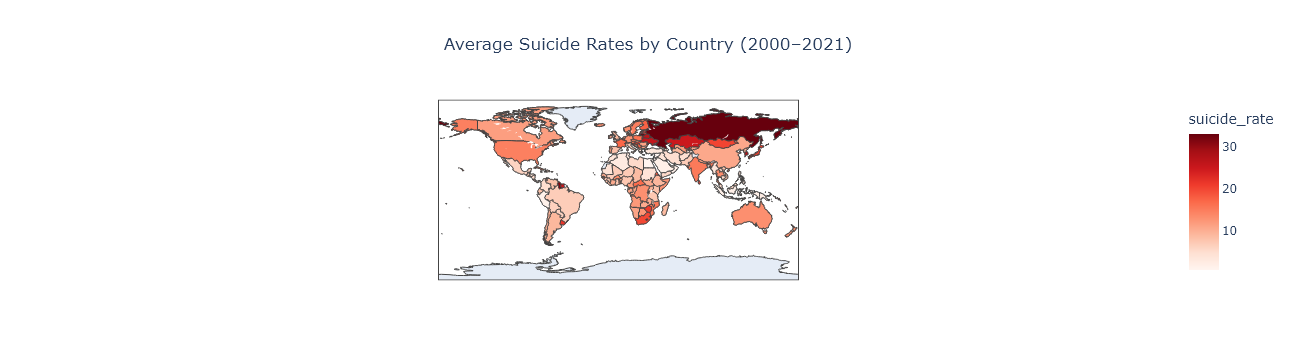

In [12]:
import plotly.express as px

country_avg = df.groupby(["iso_code","country"])["suicide_rate"].mean().reset_index()

fig = px.choropleth(
    country_avg,
    locations="iso_code",
    color="suicide_rate",
    hover_name="country",
    color_continuous_scale="Reds",
    title="Average Suicide Rates by Country (2000–2021)"
)

fig.update_layout(title_x=0.5)

fig.show()

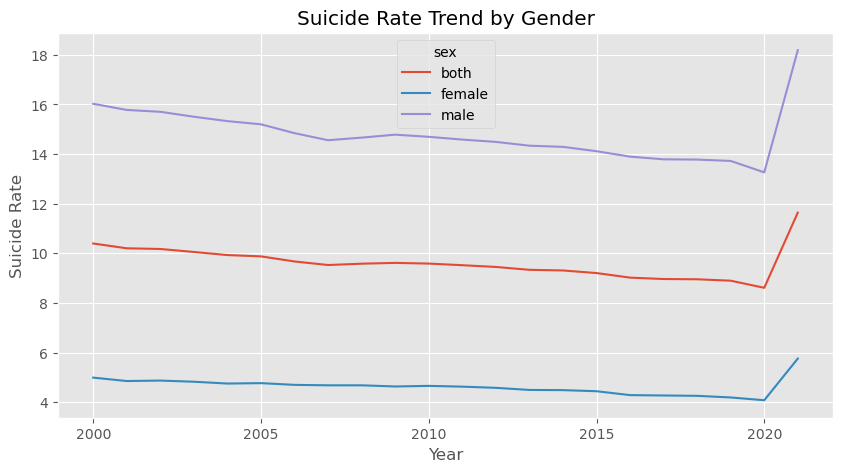

In [13]:
gender_trend = df.groupby(["year","sex"])["suicide_rate"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=gender_trend,
    x="year",
    y="suicide_rate",
    hue="sex"
)

plt.title("Suicide Rate Trend by Gender")

plt.xlabel("Year")
plt.ylabel("Suicide Rate")

plt.show()

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

country_data = df.groupby("country")["suicide_rate"].mean().reset_index()

X = country_data[["suicide_rate"]]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3)

country_data["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


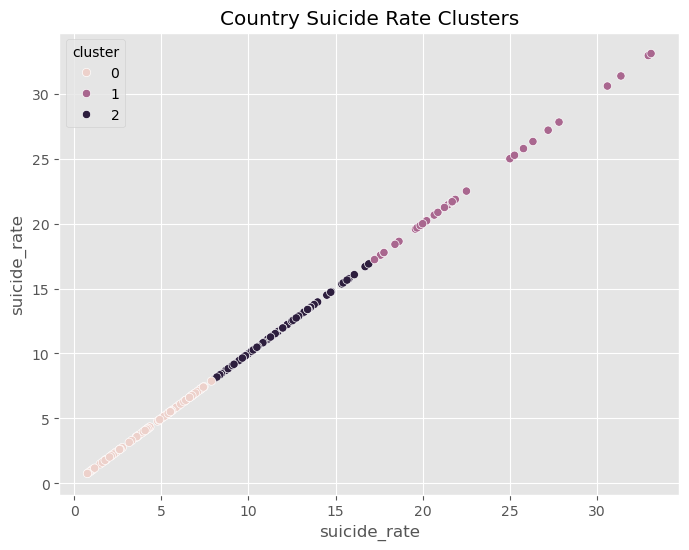

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=country_data,
    x="suicide_rate",
    y="suicide_rate",
    hue="cluster"
)

plt.title("Country Suicide Rate Clusters")

plt.show()